# E02 — controlled signed-waveform benchmark


E02 compares the seven registered misfits under controlled perturbations of a signed waveform: common positive gain, relative signed-event amplitude, time shift, and signed gain. Q-vvW2 uses one common positive-scale quotient; the experiment therefore separates true shape/polarity changes from a nuisance global gain.

The notebook prints progress for each sweep and each HV point. The two lower response maps are generated from the newly computed sweep data.

In [11]:
from IPython.display import display, Image
import os
import sys
import subprocess
from pathlib import Path

# ============================================================
# Locate the qvvw2 repository
# ============================================================

ROOT = Path.cwd().resolve()

for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "pyproject.toml").exists():
        ROOT = candidate
        break
else:
    raise RuntimeError(
        "Could not locate the qvvw2 repository root."
    )

os.chdir(ROOT)

# ============================================================
# Make sure the current repository is installed
# ============================================================

def current_qvvw2_path():
    try:
        import qvvw2
        return Path(qvvw2.__file__).resolve()
    except ImportError:
        return None


installed_path = current_qvvw2_path()

need_install = (
    installed_path is None
    or ROOT not in installed_path.parents
)

if need_install:
    print("Preparing local qvvw2 package...")

    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-e",
            str(ROOT),
            "--no-deps",
            "--no-build-isolation",
            "--quiet",
        ],
        check=True,
    )

# Make the current checkout take priority.
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import qvvw2

# ============================================================
# Environment used by experiment subprocesses
# ============================================================

existing_pythonpath = os.environ.get(
    "PYTHONPATH",
    ""
)

pythonpath_parts = [
    str(ROOT)
]

if existing_pythonpath:
    pythonpath_parts.append(
        existing_pythonpath
    )

os.environ["PYTHONPATH"] = os.pathsep.join(
    pythonpath_parts
)

print("Repository :", ROOT)
print("Python     :", sys.executable)
print("qvvw2      :", Path(qvvw2.__file__).resolve())


# ============================================================
# Helper for running experiment scripts
# ============================================================

def run_py(relative_path, *args):
    script = ROOT / relative_path

    if not script.exists():
        raise FileNotFoundError(
            f"Experiment script not found: {script}"
        )

    cmd = [
        sys.executable,
        "-u",
        str(script),
        *map(str, args),
    ]

    env = dict(os.environ)

    print(
        "\n" + "=" * 88,
        flush=True,
    )
    print(
        "RUN:",
        " ".join(cmd),
        flush=True,
    )
    print(
        "=" * 88,
        flush=True,
    )

    subprocess.run(
        cmd,
        cwd=ROOT,
        env=env,
        check=True,
    )


def reset_experiment(exp_id):
    """
    Remove only previously generated results and figures for the
    selected experiment before a fresh rerun.

    Source code, notebooks, inputs, and all other experiments are
    untouched.
    """
    import shutil

    exp = ROOT / "experiments" / exp_id

    for name in ("results", "figures"):
        path = exp / name

        if path.exists():
            shutil.rmtree(path)

    print(
        f"[{exp_id}] previous generated results/figures cleared.",
        flush=True,
    )



Repository : /root/autodl-tmp/qvvw2
Python     : /root/miniconda3/envs/qvvw2/bin/python
qvvw2      : /root/autodl-tmp/qvvw2/qvvw2/__init__.py


In [12]:
reset_experiment("E02")

[E02] previous generated results/figures cleared.


In [14]:
run_py("experiments/E02/code/run_e02.py", "--nonhv", "all")
run_py("experiments/E02/code/run_e02.py", "--hv", "all")
run_py("experiments/E02/code/run_e02.py", "--landscape")
run_py("experiments/E02/code/run_e02.py", "--validate")
run_py("experiments/E02/code/make_fig03.py")


RUN: /root/miniconda3/envs/qvvw2/bin/python -u /root/autodl-tmp/qvvw2/experiments/E02/code/run_e02.py --nonhv all
[E02][non-HV] sweep=gain: 41 points
[E02 non-HV gain]  1/41 (  2.4%)
[E02 non-HV gain]  8/41 ( 19.5%)
[E02 non-HV gain] 16/41 ( 39.0%)
[E02 non-HV gain] 24/41 ( 58.5%)
[E02 non-HV gain] 32/41 ( 78.0%)
[E02 non-HV gain] 40/41 ( 97.6%)
[E02 non-HV gain] 41/41 (100.0%)
NONHV gain 41 1.8326274743303657
[E02][non-HV] sweep=ratio: 52 points
[E02 non-HV ratio]  1/52 (  1.9%)
[E02 non-HV ratio] 10/52 ( 19.2%)
[E02 non-HV ratio] 20/52 ( 38.5%)
[E02 non-HV ratio] 30/52 ( 57.7%)
[E02 non-HV ratio] 40/52 ( 76.9%)
[E02 non-HV ratio] 50/52 ( 96.2%)
[E02 non-HV ratio] 52/52 (100.0%)
NONHV ratio 52 2.04746535141021
[E02][non-HV] sweep=shift: 61 points
[E02 non-HV shift]  1/61 (  1.6%)
[E02 non-HV shift] 12/61 ( 19.7%)
[E02 non-HV shift] 24/61 ( 39.3%)
[E02 non-HV shift] 36/61 ( 59.0%)
[E02 non-HV shift] 48/61 ( 78.7%)
[E02 non-HV shift] 60/61 ( 98.4%)
[E02 non-HV shift] 61/61 (100.0%)
NON

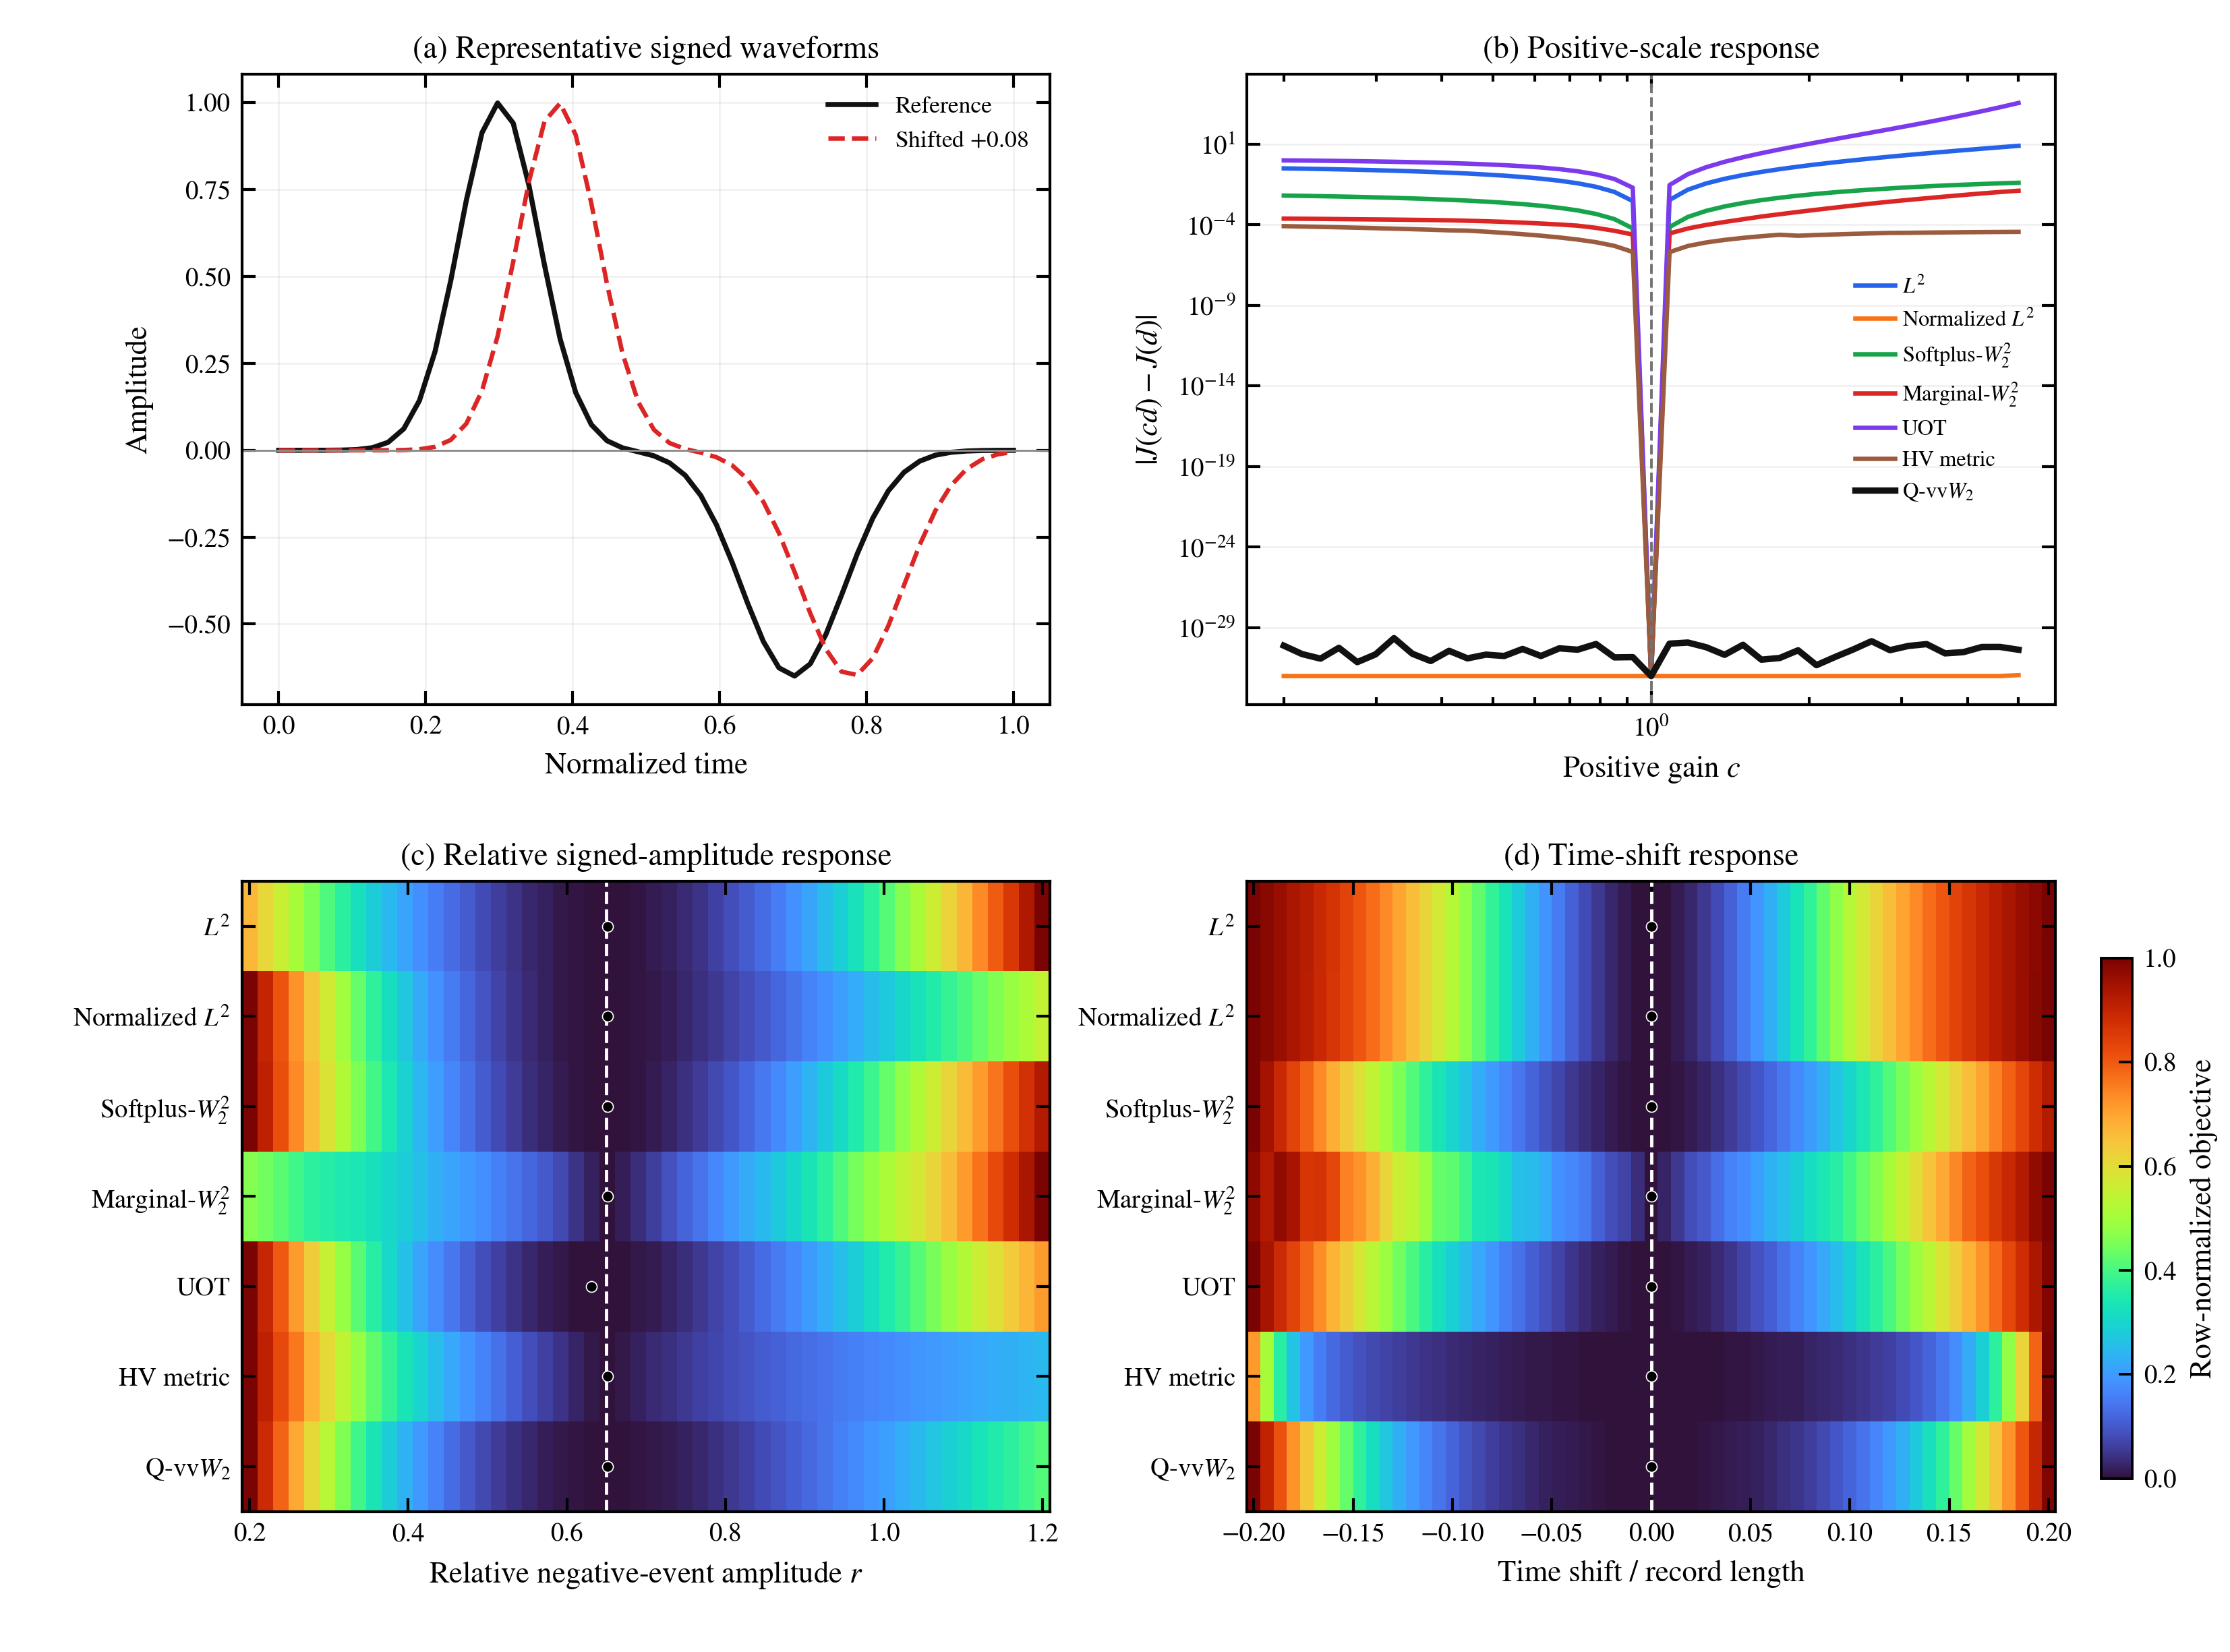

In [15]:
def show_png(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    display(Image(filename=str(path)))

show_png(ROOT / "experiments/E02/figures/Fig03_signed_waveform_mechanism.png")